# Import thư viện

In [85]:
import numpy as np 
import pandas as pd
from itables import show
from scipy.stats import skew,boxcox_normmax, zscore
import matplotlib.pyplot as plt
import seaborn as sns
import itables.options as opt
opt.maxBytes = 5000000

# Nạp dữ liệu

In [76]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

In [77]:
show(df)

Loading ITables v2.5.2 from the internet... (need help?)


# Tiền xử lý dữ liệu

## Xử lý dữ liệu thiếu:

In [78]:
train.columns

Index(['Id', 'Artist Name', 'Track Name', 'Popularity', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_in min/ms', 'time_signature', 'Class'],
      dtype='object')

In [79]:
missing_feats = ['Popularity','key','instrumentalness']

for feat in missing_feats:
    global_median = train[feat].median()
    train[feat] = train[feat].fillna(global_median)
    test[feat] = test[feat].fillna(global_median)

## Gộp train và test để cả 2 đều động bộ

In [80]:
target = train['Class']
df = pd.concat([train.drop('Class',axis=1),test])
print("\n train",train.shape)
print("\n test",test.shape)
print("\nall data",df.shape)


 train (14396, 18)

 test (3600, 17)

all data (17996, 17)


In [81]:
df.isna().sum()

Id                    0
Artist Name           0
Track Name            0
Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
dtype: int64

# Feature Engineering

C:\Users\Keqing\AppData\Local\Temp\ipykernel_4728\2324908174.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_skew.index, y=high_skew.values, palette="viridis")


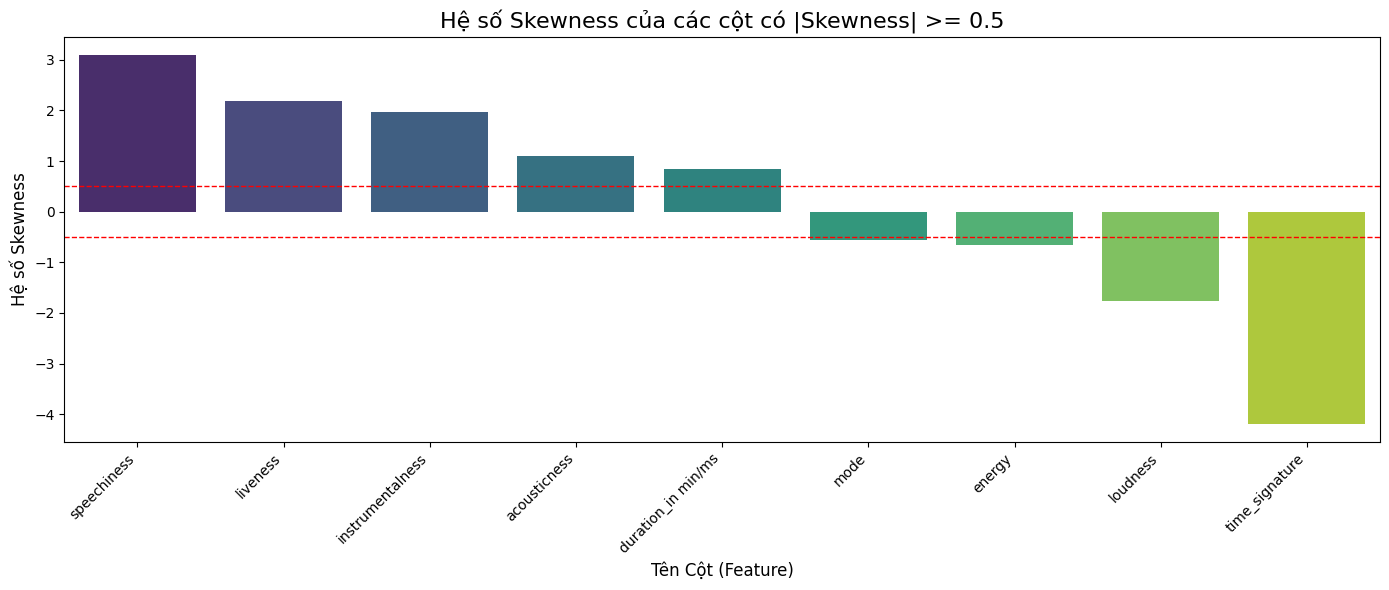

In [95]:
# --- 1. Tính toán Độ Lệch (Skewness) ---

# Chỉ chọn các cột có kiểu dữ liệu là số (định lượng) để tính Skewness
numeric_features = df.select_dtypes(include=np.number).columns


# Tính toán Skewness
skewness_series = df[numeric_features].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

# --- 2. Lọc và Trực quan hóa Độ Lệch Cao ---

# Đặt ngưỡng để lọc các cột có độ lệch đáng kể (ví dụ: |Skewness| > 0.5)
skewness_threshold = 0.5

# Lấy các cột có giá trị tuyệt đối của độ lệch lớn hơn ngưỡng
high_skew = skewness_series[abs(skewness_series) >= skewness_threshold]
# --- 3. Vẽ Biểu đồ Bar Plot ---

plt.figure(figsize=(14, 6))

# Tạo biểu đồ Bar Plot sử dụng Seaborn
sns.barplot(x=high_skew.index, y=high_skew.values, palette="viridis")

# Đặt tiêu đề và nhãn
plt.title(f'Hệ số Skewness của các cột có |Skewness| >= {skewness_threshold}', fontsize=16)
plt.xlabel('Tên Cột (Feature)', fontsize=12)
plt.ylabel('Hệ số Skewness', fontsize=12)

# Xoay nhãn trục X để dễ đọc hơn
plt.xticks(rotation=45, ha='right')

# Thêm đường tham chiếu tại y=0.5 và y=-0.5
plt.axhline(skewness_threshold, color='red', linestyle='--', linewidth=1)
plt.axhline(-skewness_threshold, color='red', linestyle='--', linewidth=1)

plt.tight_layout() # Điều chỉnh bố cục để tránh nhãn bị cắt
plt.show()

In [ ]:
log_feat = ['speechiness' , 'acousticness', 'instrumentalness', 'liveness']